# **Laboratorio 6 - Vision por Computadora**

- Paula Barillas - 22764
- Gerardo Pineda - 22880
- Monica Salvatierra - 22249

Link del repositorio: https://github.com/paulabaal12/LAB6-VCP

---

## **Task 1**
---

## **Task 2**
---

In [1]:
import os
import time
import copy
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo utilizado: {device}")

Dispositivo utilizado: cpu


In [2]:
# Transformaciones para entrenamiento
train_transform = transforms.Compose([ transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(), transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])
])

# Transformaciones para validacion y prueba
val_test_transform = transforms.Compose([
    transforms.Resize(256),transforms.CenterCrop(224),
    transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])
])

# Transformaciones para InceptionV3 (requiere 299x299)
train_transform_inception = transforms.Compose([
    transforms.RandomResizedCrop(299, scale=(0.8, 1.0)),transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(), transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transform_inception = transforms.Compose([
    transforms.Resize(320), transforms.CenterCrop(299),
    transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Transformaciones definidas")

Transformaciones definidas


#### **Entrenamiento (70%), Validacion (15%) y Prueba (15%)**

In [3]:
DATA_DIR = "data"
NUM_CLASSES = 8
BATCH_SIZE = 32

full_dataset = datasets.ImageFolder(root=DATA_DIR)
class_names = full_dataset.classes
targets = full_dataset.targets

print(f"Clases encontradas: {class_names}")
print(f"Total de imagenes: {len(full_dataset)}")
print(f"Distribucion por clase: {dict(Counter(targets))}")

# 70% train, 15% val, 15% test
indices = list(range(len(full_dataset)))
train_idx, temp_idx = train_test_split(indices, test_size=0.30, stratify=targets, random_state=42)
temp_targets = [targets[i] for i in temp_idx]
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50, stratify=temp_targets, random_state=42)

print(f"\nTamaño del conjunto de entrenamiento: {len(train_idx)} ({len(train_idx)/len(full_dataset)*100:.1f}%)")
print(f"Tamaño del conjunto de validacion: {len(val_idx)} ({len(val_idx)/len(full_dataset)*100:.1f}%)")
print(f"Tamaño del conjunto de prueba: {len(test_idx)} ({len(test_idx)/len(full_dataset)*100:.1f}%)")

Clases encontradas: ['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']
Total de imagenes: 4000
Distribucion por clase: {0: 500, 1: 500, 2: 500, 3: 500, 4: 500, 5: 500, 6: 500, 7: 500}

Tamaño del conjunto de entrenamiento: 2800 (70.0%)
Tamaño del conjunto de validacion: 600 (15.0%)
Tamaño del conjunto de prueba: 600 (15.0%)


In [4]:
class TransformedSubset(torch.utils.data.Dataset):
    """aplica una transformacion especifica a un Subset."""
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, idx):
        img, label = self.subset[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

    def __len__(self):
        return len(self.subset)

# Dataset base sin transformaciones
base_dataset = datasets.ImageFolder(root=DATA_DIR)

train_subset = Subset(base_dataset, train_idx)
val_subset = Subset(base_dataset, val_idx)
test_subset = Subset(base_dataset, test_idx)

# DataLoaders para ResNet50 y MobileNetV2
train_loader_224 = DataLoader(TransformedSubset(train_subset, train_transform), batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader_224 = DataLoader(TransformedSubset(val_subset, val_test_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader_224 = DataLoader(TransformedSubset(test_subset, val_test_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# DataLoaders para InceptionV3 (299x299)
train_loader_299 = DataLoader(TransformedSubset(train_subset, train_transform_inception), batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader_299 = DataLoader(TransformedSubset(val_subset, val_test_transform_inception), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader_299 = DataLoader(TransformedSubset(test_subset, val_test_transform_inception),batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"DataLoaders")
print(f"Batches de entrenamiento (224): {len(train_loader_224)}")
print(f"Batches de validacion (224): {len(val_loader_224)}")
print(f"Batches de prueba (224): {len(test_loader_224)}")
print(f"Batches de entrenamiento (299): {len(train_loader_299)}")
print(f"Batches de validacion (299): {len(val_loader_299)}")
print(f"Batches de prueba (299): {len(test_loader_299)}")

DataLoaders
Batches de entrenamiento (224): 88
Batches de validacion (224): 19
Batches de prueba (224): 19
Batches de entrenamiento (299): 88
Batches de validacion (299): 19
Batches de prueba (299): 19


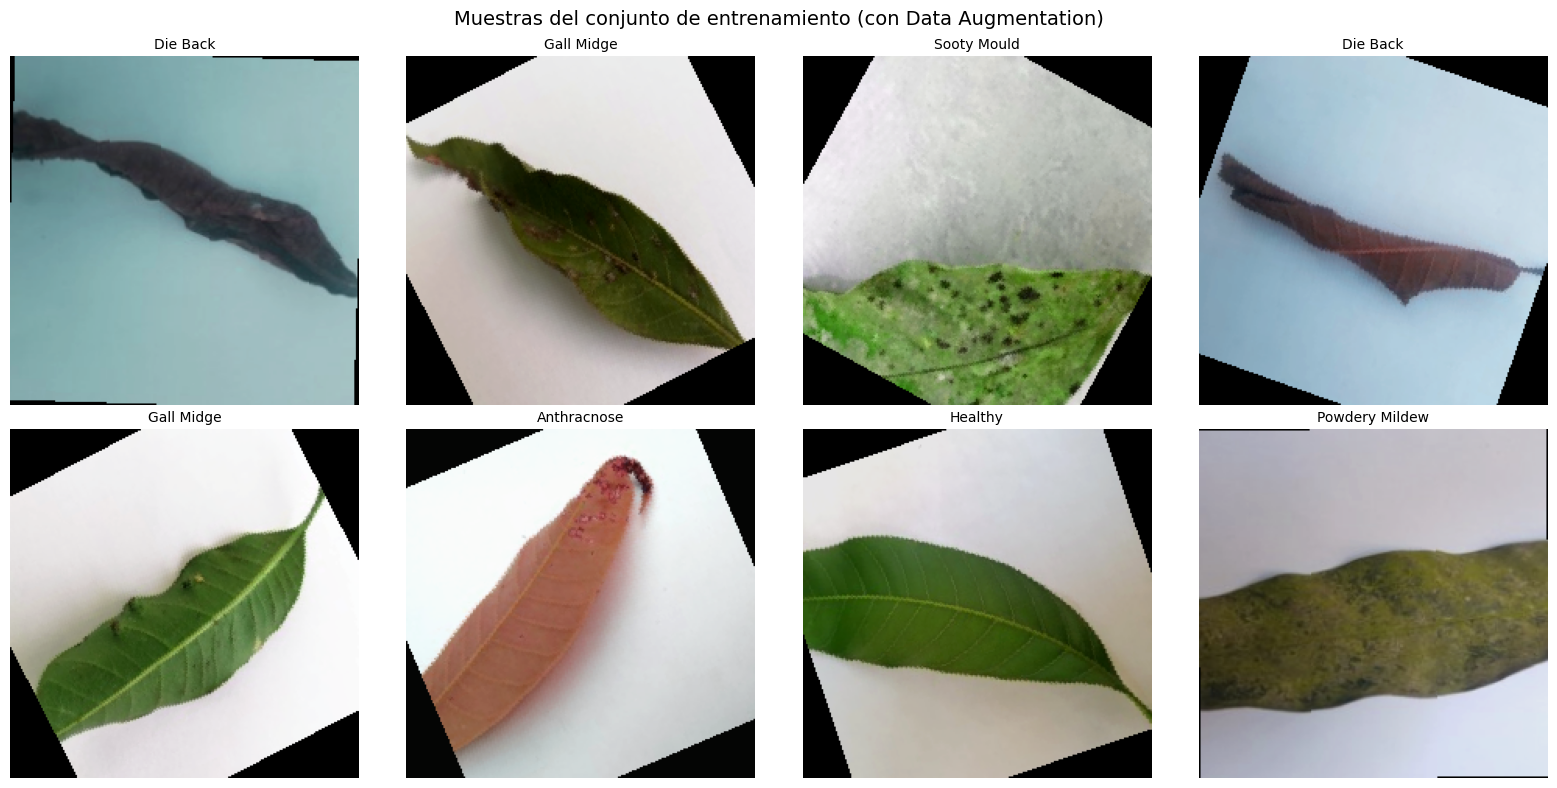

In [5]:
def imshow(inp, title=None):
    """imagen desnormalizada."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)

images, labels = next(iter(train_loader_224))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    ax.axis('off')
    inp = images[i].numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    ax.imshow(inp)
    ax.set_title(class_names[labels[i]], fontsize=10)

plt.suptitle("Muestras del conjunto de entrenamiento (con Data Augmentation)", fontsize=14)
plt.tight_layout()
plt.show()

#### **ResNet50**

In [6]:
def create_resnet50(num_classes=8):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

    # Congela todas las capas base
    for param in model.parameters():
        param.requires_grad = False

    # Reemplazar el cabezal de clasificacion
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(num_features, num_classes)
    )

    return model

resnet50 = create_resnet50(NUM_CLASSES).to(device)

total_params = sum(p.numel() for p in resnet50.parameters())
trainable_params = sum(p.numel() for p in resnet50.parameters() if p.requires_grad)
print(f"Parametros totales: {total_params:,}")
print(f"Parametros entrenables: {trainable_params:,}")
print(f"Parametros congelados: {total_params - trainable_params:,}")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\rebe1/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:03<00:00, 26.3MB/s]


Parametros totales: 23,524,424
Parametros entrenables: 16,392
Parametros congelados: 23,508,032


#### **InceptionV3**

In [7]:
def create_inceptionv3(num_classes=8):
    model = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1)

    # Congela todas las capas base
    for param in model.parameters():
        param.requires_grad = False

    # Reemplazar el cabezal de clasificacion principal
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(num_features, num_classes)
    )

    num_features_aux = model.AuxLogits.fc.in_features
    model.AuxLogits.fc = nn.Linear(num_features_aux, num_classes)

    # gradientes en los nuevos cabezales
    for param in model.fc.parameters():
        param.requires_grad = True
    for param in model.AuxLogits.fc.parameters():
        param.requires_grad = True

    return model

inceptionv3 = create_inceptionv3(NUM_CLASSES).to(device)

total_params = sum(p.numel() for p in inceptionv3.parameters())
trainable_params = sum(p.numel() for p in inceptionv3.parameters() if p.requires_grad)
print(f"Parametros totales: {total_params:,}")
print(f"Parametros entrenables: {trainable_params:,}")
print(f"Parametros congelados: {total_params - trainable_params:,}")

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to C:\Users\rebe1/.cache\torch\hub\checkpoints\inception_v3_google-0cc3c7bd.pth
100%|██████████| 104M/104M [00:04<00:00, 24.1MB/s] 


Parametros totales: 24,365,808
Parametros entrenables: 22,544
Parametros congelados: 24,343,264


#### **MobileNetV2**

In [8]:
def create_mobilenetv2(num_classes=8):
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

    # Congelar todas las capas base
    for param in model.parameters():
        param.requires_grad = False

    # Reemplazar el clasificador
    num_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(num_features, num_classes)
    )

    return model

mobilenetv2 = create_mobilenetv2(NUM_CLASSES).to(device)

total_params = sum(p.numel() for p in mobilenetv2.parameters())
trainable_params = sum(p.numel() for p in mobilenetv2.parameters() if p.requires_grad)
print(f"Parametros totales: {total_params:,}")
print(f"Parametros entrenables: {trainable_params:,}")
print(f"Parametros congelados: {total_params - trainable_params:,}")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to C:\Users\rebe1/.cache\torch\hub\checkpoints\mobilenet_v2-b0353104.pth
100%|██████████| 13.6M/13.6M [00:00<00:00, 14.5MB/s]


Parametros totales: 2,234,120
Parametros entrenables: 10,248
Parametros congelados: 2,223,872


#### **Entrenamiento de los modelos**


#### **Early Stopping**

In [9]:
def train_model(model, train_loader, val_loader, model_name, num_epochs=20, patience=5, is_inception=False):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

    best_val_loss = float('inf')
    best_model_weights = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            if is_inception:
                outputs, aux_outputs = model(inputs)
                loss1 = criterion(outputs, labels)
                loss2 = criterion(aux_outputs, labels)
                loss = loss1 + 0.4 * loss2
            else:
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_train_loss = running_loss / total
        epoch_train_acc = correct / total

        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        epoch_val_loss = val_loss / val_total
        epoch_val_acc = val_correct / val_total

        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_acc'].append(epoch_val_acc)

        print(f"[{model_name}] Epoca {epoch+1}/{num_epochs} - "
              f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} - "
              f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

        # Early Stopping
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model_weights = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"\nEarly Stopping activado en la epoca {epoch+1}. Restaurando mejores pesos.")
                break

    model.load_state_dict(best_model_weights)
    return model, history

#### **ResNet50**

In [ ]:
print("Entrenamiento de ResNet50")
print("=" * 80)
resnet50, history_resnet = train_model(
    resnet50, train_loader_224, val_loader_224,
    model_name="ResNet50", num_epochs=20, patience=5, is_inception=False
)
print("\nEntrenamiento de ResNet50 finalizado.")

Entrenamiento de ResNet50


### 3.3 Entrenamiento de InceptionV3

In [ ]:
print("Entrenamiento de InceptionV3")
print("=" * 80)
inceptionv3, history_inception = train_model(
    inceptionv3, train_loader_299, val_loader_299,
    model_name="InceptionV3", num_epochs=20, patience=5, is_inception=True
)
print("\nEntrenamiento de InceptionV3 finalizado.")

#### **MobileNetV2**

In [ ]:
print("Entrenamiento de MobileNetV2")
print("=" * 80)
mobilenetv2, history_mobilenet = train_model(
    mobilenetv2, train_loader_224, val_loader_224,
    model_name="MobileNetV2", num_epochs=20, patience=5, is_inception=False
)
print("\nEntrenamiento de MobileNetV2 finalizado.")

In [ ]:
def plot_training_curves(histories, model_names):
    fig, axes = plt.subplots(len(model_names), 2, figsize=(14, 5 * len(model_names)))

    for i, (history, name) in enumerate(zip(histories, model_names)):
        epochs_range = range(1, len(history['train_loss']) + 1)

        # perdida
        axes[i, 0].plot(epochs_range, history['train_loss'], label='Train Loss')
        axes[i, 0].plot(epochs_range, history['val_loss'], label='Val Loss')
        axes[i, 0].set_title(f'{name} - Perdida')
        axes[i, 0].set_xlabel('Epoca')
        axes[i, 0].set_ylabel('Loss')
        axes[i, 0].legend()
        axes[i, 0].grid(True, alpha=0.3)

        # exactitud
        axes[i, 1].plot(epochs_range, history['train_acc'], label='Train Acc')
        axes[i, 1].plot(epochs_range, history['val_acc'], label='Val Acc')
        axes[i, 1].set_title(f'{name} - Exactitud')
        axes[i, 1].set_xlabel('Epoca')
        axes[i, 1].set_ylabel('Accuracy')
        axes[i, 1].legend()
        axes[i, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_training_curves(
    [history_resnet, history_inception, history_mobilenet],
    ['ResNet50', 'InceptionV3', 'MobileNetV2']
)

#### **Evaluación**

In [ ]:
def evaluate_model(model, test_loader, model_name):
    """Evalua el modelo en el conjunto de prueba y retorna predicciones y etiquetas reales."""
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')

    print(f"\n{'='*60}")
    print(f"Resultados de {model_name} en el conjunto de prueba")
    print(f"{'='*60}")
    print(f"Accuracy:       {acc:.4f} ({acc*100:.2f}%)")
    print(f"F1-Score Macro: {f1:.4f}")
    print(f"\nReporte de clasificacion detallado:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    return all_preds, all_labels, acc, f1


def get_model_size_mb(model, filepath):
    """Guarda el modelo."""
    torch.save(model.state_dict(), filepath)
    size_mb = os.path.getsize(filepath) / (1024 * 1024)
    return size_mb


def measure_inference_time(model, test_loader, num_images=100):
    """Tiempo promedio de inferencia por imagen en milisegundos."""
    model.eval()
    times = []
    count = 0

    with torch.no_grad():
        for inputs, _ in test_loader:
            for i in range(inputs.size(0)):
                if count >= num_images:
                    break
                single_input = inputs[i:i+1].to(device)

                if device.type == 'cuda':
                    torch.cuda.synchronize()
                start = time.perf_counter()
                _ = model(single_input)
                if device.type == 'cuda':
                    torch.cuda.synchronize()
                end = time.perf_counter()

                times.append((end - start) * 1000)
                count += 1

            if count >= num_images:
                break

    avg_time = np.mean(times)
    return avg_time

#### **Evaluacion de ResNet50**

In [ ]:
preds_resnet, labels_resnet, acc_resnet, f1_resnet = evaluate_model(resnet50, test_loader_224, "ResNet50")
size_resnet = get_model_size_mb(resnet50, "resnet50_mango.pth")
time_resnet = measure_inference_time(resnet50, test_loader_224, num_images=100)

print(f"Tamano del modelo: {size_resnet:.2f} MB")
print(f"Tiempo de inferencia promedio: {time_resnet:.2f} ms/imagen")

#### **Evaluacion de InceptionV3**

In [ ]:
preds_inception, labels_inception, acc_inception, f1_inception = evaluate_model(inceptionv3, test_loader_299, "InceptionV3")
size_inception = get_model_size_mb(inceptionv3, "inceptionv3_mango.pth")
time_inception = measure_inference_time(inceptionv3, test_loader_299, num_images=100)

print(f"Tamano del modelo: {size_inception:.2f} MB")
print(f"Tiempo de inferencia promedio: {time_inception:.2f} ms/imagen")

#### **Evaluacion de MobileNetV2**

In [ ]:
preds_mobilenet, labels_mobilenet, acc_mobilenet, f1_mobilenet = evaluate_model(mobilenetv2, test_loader_224, "MobileNetV2")
size_mobilenet = get_model_size_mb(mobilenetv2, "mobilenetv2_mango.pth")
time_mobilenet = measure_inference_time(mobilenetv2, test_loader_224, num_images=100)

print(f"Tamano del modelo: {size_mobilenet:.2f} MB")
print(f"Tiempo de inferencia promedio: {time_mobilenet:.2f} ms/imagen")

#### **Matrices de confusión**

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

all_results = [
    (preds_resnet, labels_resnet, "ResNet50"),
    (preds_inception, labels_inception, "InceptionV3"),
    (preds_mobilenet, labels_mobilenet, "MobileNetV2")
]

for ax, (preds, labels, name) in zip(axes, all_results):
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f'Matriz de Confusion - {name}')
    ax.set_xlabel('Prediccion')
    ax.set_ylabel('Etiqueta Real')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

#### **Comparación de resultados**

In [ ]:
import pandas as pd

results_table = pd.DataFrame({
    'Modelo': ['ResNet50', 'InceptionV3', 'MobileNetV2'],
    'Accuracy (%)': [f"{acc_resnet*100:.2f}", f"{acc_inception*100:.2f}", f"{acc_mobilenet*100:.2f}"],
    'F1-Score Macro': [f"{f1_resnet:.4f}", f"{f1_inception:.4f}", f"{f1_mobilenet:.4f}"],
    'Tamano (MB)': [f"{size_resnet:.2f}", f"{size_inception:.2f}", f"{size_mobilenet:.2f}"],
    'Inferencia (ms/img)': [f"{time_resnet:.2f}", f"{time_inception:.2f}", f"{time_mobilenet:.2f}"]
})

print("\n" + "=" * 80)
print("COMPARACIÓN DE RESULTADOS")
print("=" * 80)
print(results_table.to_string(index=False))
print("=" * 80)

In [ ]:
model_names = ['ResNet50', 'InceptionV3', 'MobileNetV2']
accuracies = [acc_resnet * 100, acc_inception * 100, acc_mobilenet * 100]
f1_scores = [f1_resnet, f1_inception, f1_mobilenet]
sizes = [size_resnet, size_inception, size_mobilenet]
inf_times = [time_resnet, time_inception, time_mobilenet]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

colors = ['#2196F3', '#FF9800', '#4CAF50']

axes[0].bar(model_names, accuracies, color=colors)
axes[0].set_title('Accuracy (%)')
axes[0].set_ylim(0, 100)
for i, v in enumerate(accuracies):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

axes[1].bar(model_names, f1_scores, color=colors)
axes[1].set_title('F1-Score Macro')
axes[1].set_ylim(0, 1)
for i, v in enumerate(f1_scores):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

axes[2].bar(model_names, sizes, color=colors)
axes[2].set_title('Tamano del modelo (MB)')
for i, v in enumerate(sizes):
    axes[2].text(i, v + 1, f'{v:.1f}', ha='center', fontweight='bold')

axes[3].bar(model_names, inf_times, color=colors)
axes[3].set_title('Tiempo de inferencia (ms/img)')
for i, v in enumerate(inf_times):
    axes[3].text(i, v + 0.5, f'{v:.1f}', ha='center', fontweight='bold')

plt.suptitle('Comparacion de Modelos - Clasificacion de Hojas de Mango', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

## Prompt Utilizado

**Uso de ChatGPT**

**Task 1**


**Task 2**


**Task 3**


**Por que funciono este prompt**

---